# Лабораторная работа №1

## Аффинные преобразования. Однородные координаты

В ноутбуке выполнены оба задания первой лабораторной:
- преобразование треугольника последовательностью аффинных преобразований;
- построение аффинного отображения квадрата в параллелограмм и обратного преобразования.

Во всех вычислениях вершины хранятся в виде матрицы однородных координат размера `3 x n`, где каждая колонка соответствует вершине.


In [7]:
import math
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)


## Общие функции

Ниже определены функции для перевода точек в однородные координаты, построения матриц элементарных преобразований и визуализации многоугольников.


In [8]:
def to_homogeneous(points: np.ndarray) -> np.ndarray:
    return np.vstack([points.T, np.ones(points.shape[0])])


def from_homogeneous(points_h: np.ndarray) -> np.ndarray:
    return (points_h[:2] / points_h[2]).T


def translation(tx: float, ty: float) -> np.ndarray:
    return np.array([
        [1.0, 0.0, tx],
        [0.0, 1.0, ty],
        [0.0, 0.0, 1.0],
    ])


def rotation(angle_deg: float) -> np.ndarray:
    angle_rad = math.radians(angle_deg)
    c = math.cos(angle_rad)
    s = math.sin(angle_rad)
    return np.array([
        [c, -s, 0.0],
        [s, c, 0.0],
        [0.0, 0.0, 1.0],
    ])


def homothety(center: tuple[float, float], k: float) -> np.ndarray:
    cx, cy = center
    return translation(cx, cy) @ np.array([
        [k, 0.0, 0.0],
        [0.0, k, 0.0],
        [0.0, 0.0, 1.0],
    ]) @ translation(-cx, -cy)


def reflection_about_line(a: float, b: float, c: float) -> np.ndarray:
    norm = math.hypot(a, b)
    a, b, c = a / norm, b / norm, c / norm
    return np.array([
        [1 - 2 * a * a, -2 * a * b, -2 * a * c],
        [-2 * a * b, 1 - 2 * b * b, -2 * b * c],
        [0.0, 0.0, 1.0],
    ])


def polygon_path(points: np.ndarray) -> np.ndarray:
    return np.vstack([points, points[0]])


def plot_polygon(ax, points: np.ndarray, label: str, color: str) -> None:
    path = polygon_path(points)
    ax.plot(path[:, 0], path[:, 1], marker="o", linewidth=2, label=label, color=color)


def annotate_vertices(ax, points: np.ndarray, names: list[str], color: str) -> None:
    for name, (x, y) in zip(names, points):
        ax.text(x + 0.08, y + 0.08, name, color=color, fontsize=10)


def print_matrix(name: str, matrix: np.ndarray) -> None:
    print(f"{name} =")
    print(np.array_str(matrix, precision=4, suppress_small=True))
    print()


def print_points(name: str, points: np.ndarray) -> None:
    print(f"{name} =")
    print(np.array_str(points, precision=4, suppress_small=True))
    print()


## Задание 1.1. Преобразование треугольника

Выберем треугольник с вершинами
- `A = (0, 0)`
- `B = (4, 1)`
- `C = (1, 5)`

Параметры преобразований:
- перенос на вектор `s = (2, -1)`;
- поворот на `40°` относительно центра тяжести `Z`;
- осевая симметрия относительно прямой `n: x - y - 1 = 0`;
- гомотетия с коэффициентом `1.3` относительно начала координат `O`;
- гомотетия с коэффициентом `0.6` относительно середины наименьшей стороны.

В предоставленном `md` формула композиции содержит OCR-артефакты, поэтому здесь используется композиция преобразований, перечисленных в подпункте `(a)`:

`F = H_M(0.6) · H_O(1.3) · S_n · R_Z(40°) · T_s`

Преобразования применяются справа налево.


In [9]:
triangle = np.array([
    [0.0, 0.0],
    [4.0, 1.0],
    [1.0, 5.0],
])
triangle_names = ["A", "B", "C"]
triangle_h = to_homogeneous(triangle)

edge_pairs = [(0, 1), (1, 2), (2, 0)]
edge_lengths = np.array([
    np.linalg.norm(triangle[j] - triangle[i]) for i, j in edge_pairs
])
shortest_edge_index = int(np.argmin(edge_lengths))
shortest_edge = edge_pairs[shortest_edge_index]
midpoint_m = triangle[list(shortest_edge)].mean(axis=0)
centroid_z = triangle.mean(axis=0)

shift = translation(2.0, -1.0)
rotate_about_centroid = translation(*centroid_z) @ rotation(40.0) @ translation(*(-centroid_z))
reflect_about_n = reflection_about_line(1.0, -1.0, -1.0)
homothety_origin = homothety((0.0, 0.0), 1.3)
homothety_midpoint = homothety(tuple(midpoint_m), 0.6)

F_triangle = homothety_midpoint @ homothety_origin @ reflect_about_n @ rotate_about_centroid @ shift

triangle_after_shift = from_homogeneous(shift @ triangle_h)
triangle_after_rotate = from_homogeneous(rotate_about_centroid @ shift @ triangle_h)
triangle_after_reflect = from_homogeneous(reflect_about_n @ rotate_about_centroid @ shift @ triangle_h)
triangle_after_h0 = from_homogeneous(homothety_origin @ reflect_about_n @ rotate_about_centroid @ shift @ triangle_h)
triangle_final = from_homogeneous(F_triangle @ triangle_h)

print_points("Вершины треугольника", triangle)
print_matrix("Матрица однородных координат треугольника", triangle_h)
print(f"Центр тяжести Z = {centroid_z}")
print(f"Наименьшая сторона: {triangle_names[shortest_edge[0]]}{triangle_names[shortest_edge[1]]}, длина = {edge_lengths[shortest_edge_index]:.4f}")
print(f"Середина наименьшей стороны M = {midpoint_m}")
print()

print_matrix("T_s", shift)
print_matrix("R_Z", rotate_about_centroid)
print_matrix("S_n", reflect_about_n)
print_matrix("H_O", homothety_origin)
print_matrix("H_M", homothety_midpoint)
print_matrix("F", F_triangle)
print_points("Итоговый образ треугольника F(ABC)", triangle_final)


Вершины треугольника =
[[0. 0.]
 [4. 1.]
 [1. 5.]]

Матрица однородных координат треугольника =
[[0. 4. 1.]
 [0. 1. 5.]
 [1. 1. 1.]]

Центр тяжести Z = [1.6667 2.    ]
Наименьшая сторона: AB, длина = 4.1231
Середина наименьшей стороны M = [2.  0.5]

T_s =
[[ 1.  0.  2.]
 [ 0.  1. -1.]
 [ 0.  0.  1.]]

R_Z =
[[ 0.766  -0.6428  1.6755]
 [ 0.6428  0.766  -0.6034]
 [ 0.      0.      1.    ]]

S_n =
[[ 0.  1.  1.]
 [ 1.  0. -1.]
 [ 0.  0.  1.]]

H_O =
[[1.3 0.  0. ]
 [0.  1.3 0. ]
 [0.  0.  1. ]]

H_M =
[[0.6 0.  0.8]
 [0.  0.6 0.2]
 [0.  0.  1. ]]

F =
[[ 0.5014  0.5975  1.5146]
 [ 0.5975 -0.5014  2.4233]
 [ 0.      0.      1.    ]]

Итоговый образ треугольника F(ABC) =
[[1.5146 2.4233]
 [4.1176 4.312 ]
 [5.0035 0.5139]]



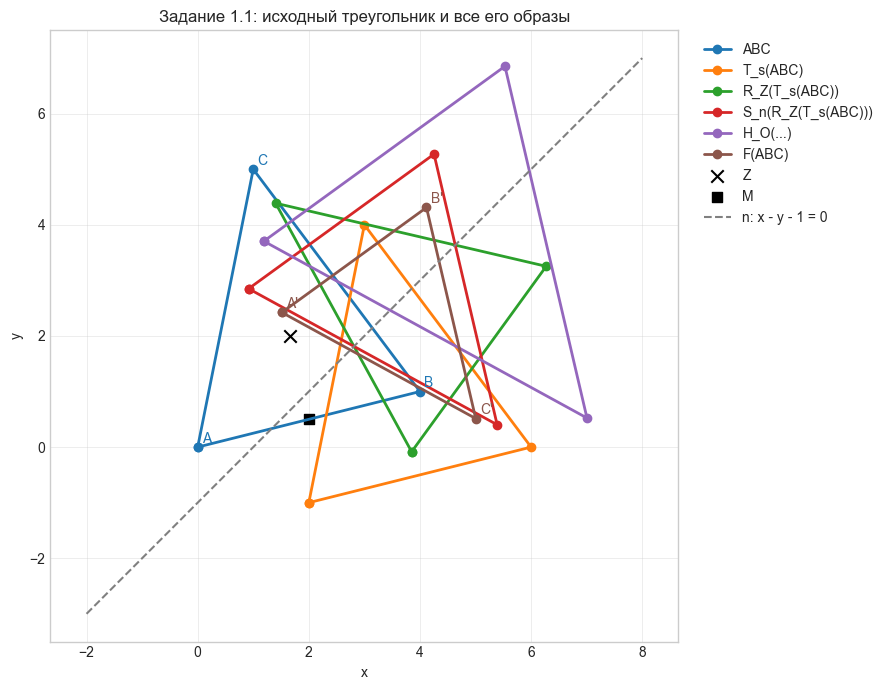

In [10]:
stages = [
    ("ABC", triangle, "tab:blue"),
    ("T_s(ABC)", triangle_after_shift, "tab:orange"),
    ("R_Z(T_s(ABC))", triangle_after_rotate, "tab:green"),
    ("S_n(R_Z(T_s(ABC)))", triangle_after_reflect, "tab:red"),
    ("H_O(...)", triangle_after_h0, "tab:purple"),
    ("F(ABC)", triangle_final, "tab:brown"),
]

fig, ax = plt.subplots(figsize=(9, 7))
for label, pts, color in stages:
    plot_polygon(ax, pts, label, color)

annotate_vertices(ax, triangle, triangle_names, "tab:blue")
annotate_vertices(ax, triangle_final, [f"{name}'" for name in triangle_names], "tab:brown")
ax.scatter(*centroid_z, color="black", marker="x", s=80, label="Z")
ax.scatter(*midpoint_m, color="black", marker="s", s=50, label="M")

x_values = np.linspace(-2, 8, 200)
y_values = x_values - 1
ax.plot(x_values, y_values, linestyle="--", color="gray", label="n: x - y - 1 = 0")

ax.set_title("Задание 1.1: исходный треугольник и все его образы")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.axis("equal")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()


## Задание 1.2. Преобразование квадрата

Выберем единичный квадрат
- `A = (0, 0)`
- `B = (1, 0)`
- `C = (1, 1)`
- `D = (0, 1)`

Тогда диагональ `AC` задает луч из `A`, а условие для вершины образа `W` дает

`W = A + 3(C - A) = (3, 3)`.

Чтобы образ стороны `AD` был параллелен `AD` и вдвое длиннее, берем вектор

`v = WZ = (0, 2)`.

Высота параллелограмма к стороне `WZ` должна быть равна `2`, а угол при `W` равен `pi / 3`. Тогда для вектора `u = WX`:
- `|u| * sin(pi / 3) = 2`,
- `u_x = 2`,
- `u_y = 2 / sqrt(3)`.

Получаем
- `X = W + u = (5, 3 + 2 / sqrt(3))`
- `Y = W + u + v = (5, 5 + 2 / sqrt(3))`
- `Z = W + v = (3, 5)`.

Линейная часть аффинного преобразования переводит базисные векторы квадрата в `u` и `v`, поэтому удобно представить `F` как композицию:

`F = T_(3,3) · Sh_y(1 / sqrt(3)) · H_O(2)`

где
- `H_O(2)` — гомотетия относительно начала координат,
- `Sh_y(k)` — сдвиг по оси `y`: `(x, y) -> (x, y + kx)`,
- `T_(3,3)` — перенос.


In [11]:
square = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [1.0, 1.0],
    [0.0, 1.0],
])
square_names = ["A", "B", "C", "D"]
square_h = to_homogeneous(square)
A, B, C, D = square

W = A + 3 * (C - A)
u = np.array([2.0, 2.0 / math.sqrt(3)])
v = np.array([0.0, 2.0])
X = W + u
Y = W + u + v
Z = W + v
parallelogram = np.vstack([W, X, Y, Z])
parallelogram_names = ["W", "X", "Y", "Z"]
parallelogram_h = to_homogeneous(parallelogram)

scale_2 = homothety((0.0, 0.0), 2.0)
shear_y = np.array([
    [1.0, 0.0, 0.0],
    [1.0 / math.sqrt(3), 1.0, 0.0],
    [0.0, 0.0, 1.0],
])
shift_to_W = translation(*W)

F_square = shift_to_W @ shear_y @ scale_2
F_square_inv = np.linalg.inv(F_square)

image_of_square_h = F_square @ square_h
preimage_of_parallelogram_h = F_square_inv @ parallelogram_h
image_of_square = from_homogeneous(image_of_square_h)
preimage_of_parallelogram = from_homogeneous(preimage_of_parallelogram_h)

height = abs(np.linalg.det(np.vstack([u, v]))) / np.linalg.norm(v)
angle_deg = math.degrees(
    math.acos(np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v)))
)

assert np.allclose(image_of_square, parallelogram)
assert np.allclose(preimage_of_parallelogram, square)

print_points("Квадрат ABCD", square)
print_matrix("Матрица однородных координат квадрата", square_h)
print_points("Параллелограмм WXYZ", parallelogram)
print_matrix("Матрица однородных координат параллелограмма", parallelogram_h)

print_matrix("H_O(2)", scale_2)
print_matrix("Sh_y(1 / sqrt(3))", shear_y)
print_matrix("T_(3, 3)", shift_to_W)
print_matrix("F", F_square)
print_matrix("F^{-1}", F_square_inv)

print_matrix("Матрица однородных координат образа F(ABCD)", image_of_square_h)
print_matrix("Матрица однородных координат прообраза F^{-1}(WXYZ)", preimage_of_parallelogram_h)
print_points("F(ABCD)", image_of_square)
print_points("F^{-1}(WXYZ)", preimage_of_parallelogram)

print(f"Проверка W на луче AC: {np.allclose(W, A + 3 * (C - A))}")
print(f"Длина WZ = {np.linalg.norm(v):.4f}")
print(f"Угол при W = {angle_deg:.4f} градуса")
print(f"Высота к стороне WZ = {height:.4f}")
print(f"F(ABCD) = WXYZ: {np.allclose(image_of_square, parallelogram)}")
print(f"F^(-1)(WXYZ) = ABCD: {np.allclose(preimage_of_parallelogram, square)}")


Квадрат ABCD =
[[0. 0.]
 [1. 0.]
 [1. 1.]
 [0. 1.]]

Матрица однородных координат квадрата =
[[0. 1. 1. 0.]
 [0. 0. 1. 1.]
 [1. 1. 1. 1.]]

Параллелограмм WXYZ =
[[3.     3.    ]
 [5.     4.1547]
 [5.     6.1547]
 [3.     5.    ]]

Матрица однородных координат параллелограмма =
[[3.     5.     5.     3.    ]
 [3.     4.1547 6.1547 5.    ]
 [1.     1.     1.     1.    ]]

H_O(2) =
[[2. 0. 0.]
 [0. 2. 0.]
 [0. 0. 1.]]

Sh_y(1 / sqrt(3)) =
[[1.     0.     0.    ]
 [0.5774 1.     0.    ]
 [0.     0.     1.    ]]

T_(3, 3) =
[[1. 0. 3.]
 [0. 1. 3.]
 [0. 0. 1.]]

F =
[[2.     0.     3.    ]
 [1.1547 2.     3.    ]
 [0.     0.     1.    ]]

F^{-1} =
[[ 0.5     0.     -1.5   ]
 [-0.2887  0.5    -0.634 ]
 [ 0.      0.      1.    ]]

Матрица однородных координат образа F(ABCD) =
[[3.     5.     5.     3.    ]
 [3.     4.1547 6.1547 5.    ]
 [1.     1.     1.     1.    ]]

Матрица однородных координат прообраза F^{-1}(WXYZ) =
[[0. 1. 1. 0.]
 [0. 0. 1. 1.]
 [1. 1. 1. 1.]]

F(ABCD) =
[[3.     3.   

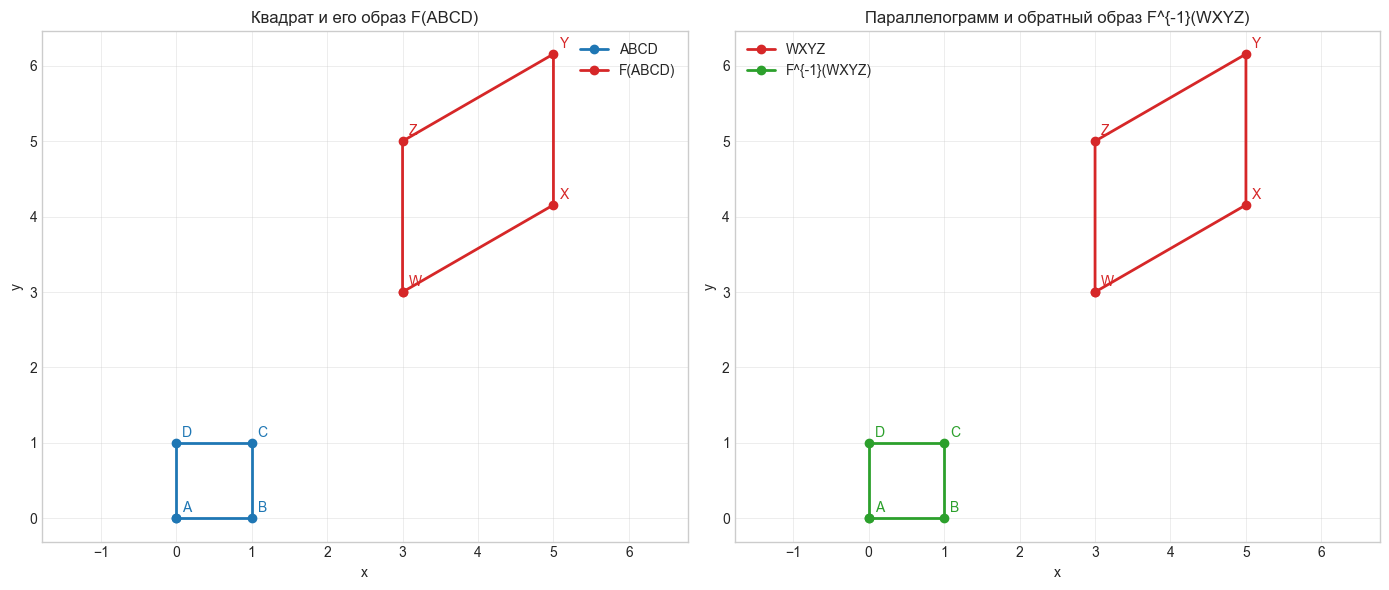

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_polygon(axes[0], square, "ABCD", "tab:blue")
plot_polygon(axes[0], image_of_square, "F(ABCD)", "tab:red")
annotate_vertices(axes[0], square, square_names, "tab:blue")
annotate_vertices(axes[0], image_of_square, parallelogram_names, "tab:red")
axes[0].set_title("Квадрат и его образ F(ABCD)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].axis("equal")
axes[0].legend()

plot_polygon(axes[1], parallelogram, "WXYZ", "tab:red")
plot_polygon(axes[1], preimage_of_parallelogram, "F^{-1}(WXYZ)", "tab:green")
annotate_vertices(axes[1], parallelogram, parallelogram_names, "tab:red")
annotate_vertices(axes[1], preimage_of_parallelogram, square_names, "tab:green")
axes[1].set_title("Параллелограмм и обратный образ F^{-1}(WXYZ)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].axis("equal")
axes[1].legend()

plt.tight_layout()
plt.show()


## Вывод

В ноутбуке построены матрицы однородных координат и матрицы аффинных преобразований для обеих задач лабораторной работы №1. Для задания 1.2 вычислительно подтверждено, что
- `F(ABCD) = WXYZ`,
- `F^{-1}(WXYZ) = ABCD`.
